## Converting a CFG to CNF
The following will be a conversion of a context-free grammar of any form into Chompsky Normal Form

This conversion has four main steps:
1) Ensure the start variable is not on the RHS
2) Eliminate $\epsilon$-rules by first finding nullable variables
3) Eliminate unit rules
4) RHS is either one terminal or just variables

In [126]:
def display_grammar(grammar):
    for key in grammar:
        print(key, '->', ' | '.join(grammar[key]))

In [127]:
grammar = {
    "S":["AaB", "b"],
    "A":["S", "e", "AB"],
    "B":["bbb","ASA"],
}

display_grammar(grammar)

S -> AaB | b
A -> S | e | AB
B -> bbb | ASA


Step 1: Ensure the start variable is not on the RHS

In [128]:
# begin by adding S0 -> S to the grammar
grammar["S0"] = ["S"]

Step 2: Eliminate $\epsilon$-rules by first finding nullable variables

In [129]:
nullable_vars = []

# first, find the variables that can make e directly
for key in grammar:
    if "e" in grammar[key]:
        nullable_vars.append(key)

# Note, we'll need to include code for the indirect transformations eventually

For each appearance of the nullable variable in the grammar, add a rule where that variable is replaced by $\epsilon$

In [130]:
import itertools

def replace_chars(s, chars_to_replace, replacement_char):
    """
    Replaces characters in a string with a replacement character using itertools.

    Args:
        s: The input string.
        chars_to_replace: A list of characters to replace.
        replacement_char: The character to replace with.

    Returns:
        A list of strings with characters replaced.
    """
    indices_to_replace = [i for i, char in enumerate(s) if char in chars_to_replace]
    results = []

    if not indices_to_replace:
        return []

    max_replacements = len(indices_to_replace)

    for r in range(max_replacements + 1):
        for indices in itertools.combinations(indices_to_replace, r):
            new_s = list(s)
            for index in indices:
                new_s[index] = replacement_char
            results.append("".join(new_s))

    return results

In [131]:
for char in nullable_vars: # eliminate each variable that can make e directly
    for variable, rules in grammar.items():
        to_append = []

        for rule in rules:
            new_rules = replace_chars(rule, char, "")
            to_append.extend(new_rules)

        grammar[variable].extend(to_append)
        grammar[variable] = list(set(grammar[variable]))

Finally, remove all $\epsilon$ productions

In [132]:
for variable, rules in grammar.items():
    if "e" in rules:
        rules.remove("e")

In [133]:
display_grammar(grammar)

S -> AaB | aB | b
A -> B | AB | S
B -> S | ASA | SA | AS | bbb
S0 -> S


Step 3: Eliminate unit rules

In [134]:
# next, we make a graph for all unit rules
unit_rules = {}

for key in grammar:
    unit_rules[key] = []
    for rule in grammar[key]:
        if rule in grammar.keys():
            unit_rules[key].append(rule)

edges = []
for start, ends in unit_rules.items():
    for end in ends:
        edges.append((start, end))

display_grammar(unit_rules)

S -> 
A -> B | S
B -> S
S0 -> S


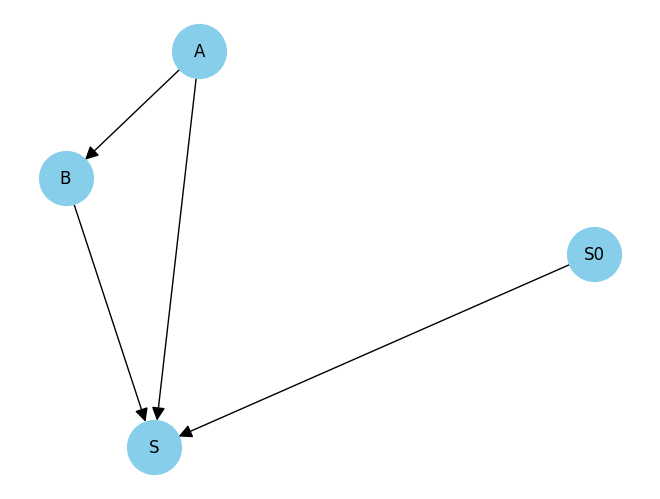

In [135]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_directed_graph(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    pos = nx.spring_layout(G)  # Layout mehod

    nx.draw(G, pos, with_labels=True, node_size=1500, node_color='skyblue', arrowsize=20)

    plt.show()

    return G

# Example usage
node_graph = visualize_directed_graph(edges)

In [136]:
# then, all rules that can be reached by unit rules
# have their rules added to the original variable
for v1, rule in grammar.items():
    for v2 in grammar.keys():
        if nx.has_path(node_graph, v1, v2):
            grammar[v1].extend(grammar[v2])
            grammar[v1] = list(set(grammar[v1]))

# then remove the unit rules
for variable, rule in grammar.items():
    grammar[variable] = [r for r in rule if r not in grammar.keys()]
display_grammar(grammar)

S -> AaB | aB | b
A -> AB | ASA | aB | SA | AaB | AS | bbb | b
B -> ASA | aB | SA | AaB | AS | bbb | b
S0 -> b | aB | AaB


Step 4: RHS is either one terminal or just variables

In [137]:
new_grammar = grammar.copy()

for variable, rules in grammar.items():
    replacements = set()
    for rule in rules:
        # if a rule contains anything but single terminals,
        # replace those terminals with a variable
        if len(rule) == 1:
            continue
        for char in rule:
            if char.islower():
                replacements.add(rule)

    for rule in replacements:
        new_grammar[variable].remove(rule)

        result = ""
        for char in rule:
            if char.islower():
                new_grammar[f"U{char}"] = [char]
                result += f"U{char}"
            else:
                result += char

        new_grammar[variable].append(result)

display_grammar(new_grammar)


S -> b | AUaB | UaB
A -> AB | ASA | SA | AS | b | UbUbUb | AUaB | UaB
B -> ASA | SA | AS | b | UbUbUb | AUaB | UaB
S0 -> b | AUaB | UaB
Ua -> a
Ub -> b
